In [1]:
from sklearn.datasets import make_moons
import torch
import matplotlib.pyplot as plt
from torch import nn, optim
from sklearn.model_selection import train_test_split
from torch.utils.data  import DataLoader, TensorDataset

In [2]:
X, y = make_moons(n_samples=500, noise=0.25, random_state=42) # Generate 2 crescent shaped data points, with some noise

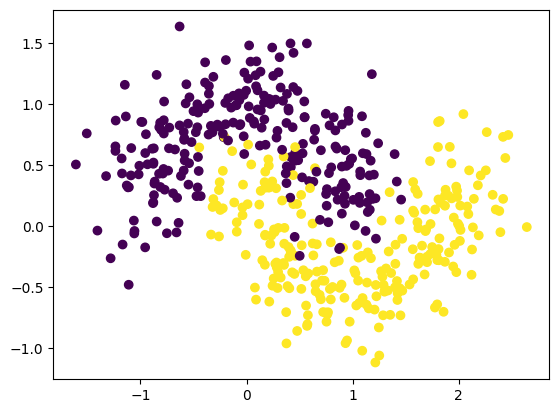

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [7]:
# Split into train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42,
                                                  shuffle=True, train_size=0.8)

In [8]:
# Convert into tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_val_t = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

In [9]:
train_dataset = TensorDataset(X_train_t, y_train_t)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

In [10]:
# Train a simple model with no dropout or normalization
model = nn.Sequential(
    nn.Linear(2, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

losses_train = []
losses_val_baseline = []

loss_ft = nn.BCELoss()
opt = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(200):

  total_train_loss = 0
  model.train()

  for X_batch, y_batch in train_loader:
    pred_train = model(X_batch)
    loss_train = loss_ft(pred_train, y_batch)
    loss_train.backward()
    opt.step()
    opt.zero_grad()
    total_train_loss += loss_train.item()

  avg_train_loss = total_train_loss / len(train_loader)

  model.eval()
  with torch.no_grad():
    pred_val = model(X_val_t)
    loss_val = loss_ft(pred_val, y_val_t)

  if epoch % 20 == 0 or epoch == 199:
    print(f'Epoch {epoch}')
    print(f'Training set loss: {avg_train_loss:.4f}')
    print(f'Validation set loss: {loss_val:.4f}')

  losses_train.append(avg_train_loss)
  losses_val_baseline.append(loss_val.item())

Epoch 0
Training set loss: 0.6061
Validation set loss: 0.4793
Epoch 20
Training set loss: 0.1069
Validation set loss: 0.1671
Epoch 40
Training set loss: 0.0938
Validation set loss: 0.1367
Epoch 60
Training set loss: 0.0924
Validation set loss: 0.1578
Epoch 80
Training set loss: 0.0871
Validation set loss: 0.1312
Epoch 100
Training set loss: 0.0922
Validation set loss: 0.1397
Epoch 120
Training set loss: 0.0971
Validation set loss: 0.2069
Epoch 140
Training set loss: 0.0922
Validation set loss: 0.1287
Epoch 160
Training set loss: 0.0744
Validation set loss: 0.1799
Epoch 180
Training set loss: 0.0736
Validation set loss: 0.1766
Epoch 199
Training set loss: 0.0705
Validation set loss: 0.1847


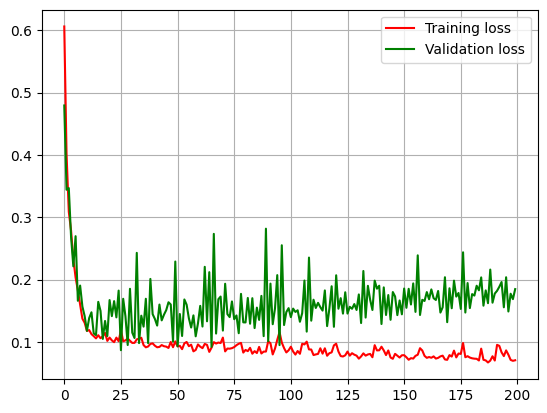

In [11]:
plt.plot(losses_train, color='red', label='Training loss')
plt.plot(losses_val_baseline, color='green', label='Validation loss')
plt.legend()
plt.grid()
plt.show()

Overfitting, since the difference between the val and train losses grows

In [12]:
# Now train with Dropout (deactivating some neurons)
model = nn.Sequential(
    nn.Linear(2, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

losses_train = []
losses_val_dropout = []

loss_ft = nn.BCELoss()
opt = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(200):

  total_train_loss = 0
  model.train()

  for X_batch, y_batch in train_loader:
    pred_train = model(X_batch)
    loss_train = loss_ft(pred_train, y_batch)
    loss_train.backward()
    opt.step()
    opt.zero_grad()
    total_train_loss += loss_train.item()

  avg_train_loss = total_train_loss / len(train_loader)

  model.eval()
  with torch.no_grad():
    pred_val = model(X_val_t)
    loss_val = loss_ft(pred_val, y_val_t)

  if epoch % 20 == 0 or epoch == 199:
    print(f'Epoch {epoch}')
    print(f'Training set loss: {avg_train_loss:.4f}')
    print(f'Validation set loss: {loss_val:.4f}')

  losses_train.append(avg_train_loss)
  losses_val_dropout.append(loss_val.item())

Epoch 0
Training set loss: 0.6448
Validation set loss: 0.5320
Epoch 20
Training set loss: 0.1362
Validation set loss: 0.1165
Epoch 40
Training set loss: 0.1173
Validation set loss: 0.1345
Epoch 60
Training set loss: 0.1170
Validation set loss: 0.1351
Epoch 80
Training set loss: 0.1114
Validation set loss: 0.1617
Epoch 100
Training set loss: 0.1089
Validation set loss: 0.1309
Epoch 120
Training set loss: 0.1133
Validation set loss: 0.1610
Epoch 140
Training set loss: 0.1008
Validation set loss: 0.1796
Epoch 160
Training set loss: 0.0854
Validation set loss: 0.1511
Epoch 180
Training set loss: 0.0979
Validation set loss: 0.1615
Epoch 199
Training set loss: 0.1032
Validation set loss: 0.1875


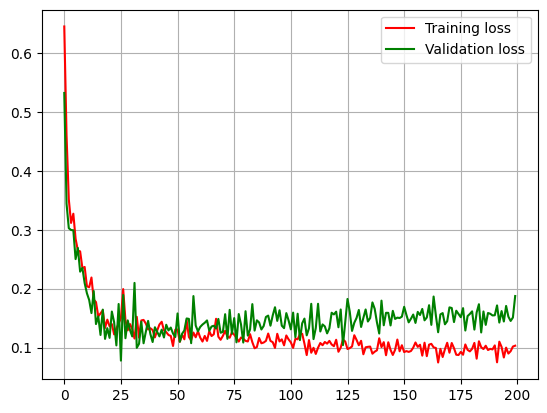

In [13]:
plt.plot(losses_train, color='red', label='Training loss')
plt.plot(losses_val_dropout, color='green', label='Validation loss')
plt.legend()
plt.grid()
plt.show()

Still overfitting, but slightly less

In [14]:
# Now train with only Batch Norm.
model = nn.Sequential(
    nn.Linear(2, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

losses_train = []
losses_val_batch = []

loss_ft = nn.BCELoss()
opt = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(200):

  total_train_loss = 0
  model.train()

  for X_batch, y_batch in train_loader:
    pred_train = model(X_batch)
    loss_train = loss_ft(pred_train, y_batch)
    loss_train.backward()
    opt.step()
    opt.zero_grad()
    total_train_loss += loss_train.item()

  avg_train_loss = total_train_loss / len(train_loader)

  model.eval()
  with torch.no_grad():
    pred_val = model(X_val_t)
    loss_val = loss_ft(pred_val, y_val_t)

  if epoch % 20 == 0 or epoch == 199:
    print(f'Epoch {epoch}')
    print(f'Training set loss: {avg_train_loss:.4f}')
    print(f'Validation set loss: {loss_val:.4f}')

  losses_train.append(avg_train_loss)
  losses_val_batch.append(loss_val.item())

Epoch 0
Training set loss: 0.3352
Validation set loss: 0.4889
Epoch 20
Training set loss: 0.2122
Validation set loss: 0.1537
Epoch 40
Training set loss: 0.1582
Validation set loss: 0.1445
Epoch 60
Training set loss: 0.1514
Validation set loss: 0.1672
Epoch 80
Training set loss: 0.1653
Validation set loss: 0.1677
Epoch 100
Training set loss: 0.1493
Validation set loss: 0.1519
Epoch 120
Training set loss: 0.1450
Validation set loss: 0.1812
Epoch 140
Training set loss: 0.1422
Validation set loss: 0.1451
Epoch 160
Training set loss: 0.1623
Validation set loss: 0.1565
Epoch 180
Training set loss: 0.1586
Validation set loss: 0.1675
Epoch 199
Training set loss: 0.1462
Validation set loss: 0.1785


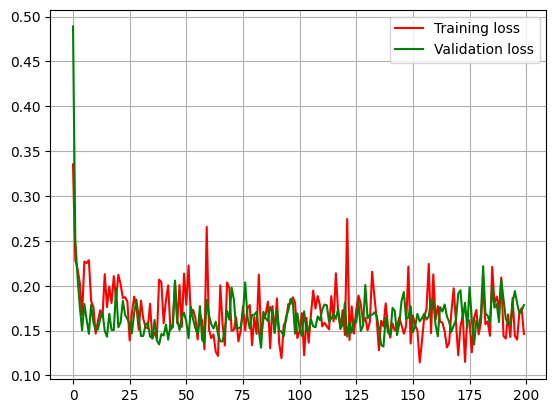

In [15]:
plt.plot(losses_train, color='red', label='Training loss')
plt.plot(losses_val_batch, color='green', label='Validation loss')
plt.legend()
plt.grid()
plt.show()

In [16]:
# Now train with both Dropout and Batch Norm.
model = nn.Sequential(
    nn.Linear(2, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

losses_train = []
losses_val_both = []

loss_ft = nn.BCELoss()
opt = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(200):

  total_train_loss = 0
  model.train()

  for X_batch, y_batch in train_loader:
    pred_train = model(X_batch)
    loss_train = loss_ft(pred_train, y_batch)
    loss_train.backward()
    opt.step()
    opt.zero_grad()
    total_train_loss += loss_train.item()

  avg_train_loss = total_train_loss / len(train_loader)

  model.eval()
  with torch.no_grad():
    pred_val = model(X_val_t)
    loss_val = loss_ft(pred_val, y_val_t)

  if epoch % 20 == 0 or epoch == 199:
    print(f'Epoch {epoch}')
    print(f'Training set loss: {avg_train_loss:.4f}')
    print(f'Validation set loss: {loss_val:.4f}')

  losses_train.append(avg_train_loss)
  losses_val_both.append(loss_val.item())

Epoch 0
Training set loss: 0.4796
Validation set loss: 0.4672
Epoch 20
Training set loss: 0.2070
Validation set loss: 0.1493
Epoch 40
Training set loss: 0.1724
Validation set loss: 0.1599
Epoch 60
Training set loss: 0.2117
Validation set loss: 0.1471
Epoch 80
Training set loss: 0.3155
Validation set loss: 0.1701
Epoch 100
Training set loss: 0.2335
Validation set loss: 0.1465
Epoch 120
Training set loss: 0.1628
Validation set loss: 0.1260
Epoch 140
Training set loss: 0.1918
Validation set loss: 0.1481
Epoch 160
Training set loss: 0.2416
Validation set loss: 0.1738
Epoch 180
Training set loss: 0.1735
Validation set loss: 0.1516
Epoch 199
Training set loss: 0.1949
Validation set loss: 0.1537


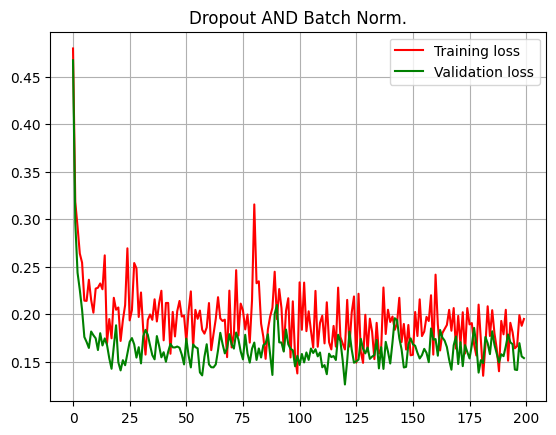

In [17]:
plt.plot(losses_train, color='red', label='Training loss')
plt.plot(losses_val_both, color='green', label='Validation loss')
plt.legend()
plt.grid()
plt.title('Dropout AND Batch Norm.')
plt.show()

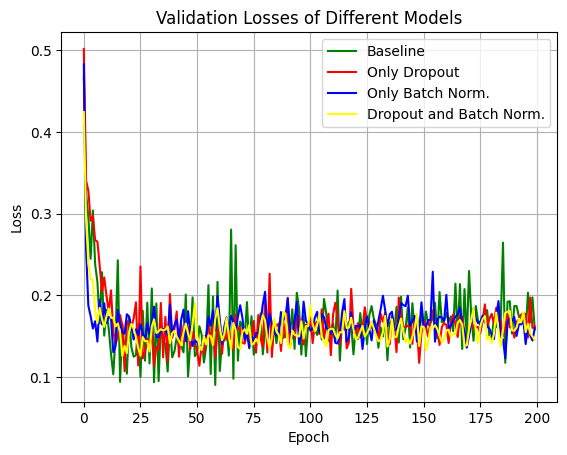

In [ ]:
plt.plot(losses_val_baseline, color='green', label='Baseline')
plt.plot(losses_val_dropout, color='red', label='Only Dropout')
plt.plot(losses_val_batch, color='blue', label='Only Batch Norm.')
plt.plot(losses_val_both, color='yellow', label='Dropout and Batch Norm.')
plt.title('Validation Losses of Different Models')
plt.grid()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()